# Verify Test Dataset

Quick visual check that the test dataset was created correctly.
Shows DAPI channel with core boundaries and cell/nuclei segmentation overlays.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile as tf
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon

test_dir = Path("../test-data")

## Load data

In [8]:
# Load image and channel names
img = tf.imread(test_dir / "test_image.tiff")
with open(test_dir / "channel_names.json") as f:
    ch_info = json.load(f)
channel_names = ch_info["channel_names"]

dapi_idx = channel_names.index("DAPI")
dapi = img[dapi_idx]
print(f"Image shape: {img.shape}")
print(f"DAPI channel index: {dapi_idx}")
print(f"DAPI range: [{dapi.min()}, {dapi.max()}]")

Image shape: (55, 3167, 12999)
DAPI channel index: 0
DAPI range: [0, 13163]


In [9]:
# Load core segmentations
with open(test_dir / "test_cores.geojson") as f:
    cores = json.load(f)
print(f"Cores: {[feat['properties']['name'] for feat in cores['features']]}")

Cores: ['A-4', 'A-5', 'A-6', 'A-7']


In [10]:
# Load cell segmentations (may take a moment)
with open(test_dir / "test_cells.geojson") as f:
    cells = json.load(f)
print(f"Number of cells: {len(cells['features'])}")

Number of cells: 54322


## Plot 1: DAPI + Core boundaries

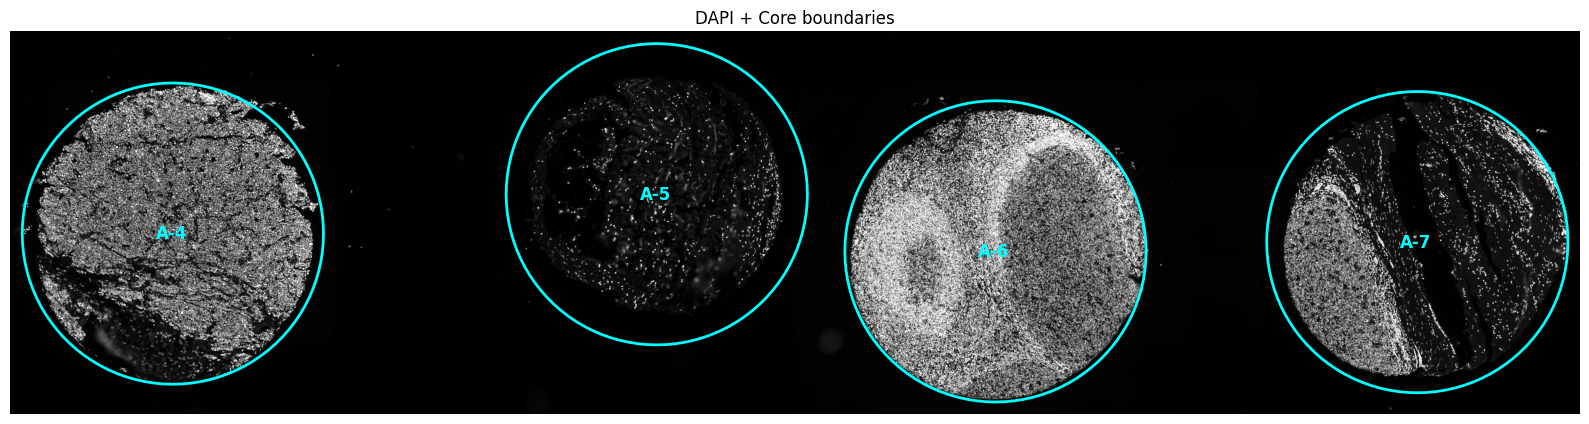

In [11]:
# Normalize DAPI for display
p1, p99 = np.percentile(dapi, [1, 99])
dapi_norm = np.clip((dapi - p1) / (p99 - p1), 0, 1)

fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(dapi_norm, cmap="gray")

for feat in cores["features"]:
    coords = np.array(feat["geometry"]["coordinates"][0])
    # geojson coords are [x, y], matplotlib Polygon expects (x, y)
    poly = Polygon(coords, closed=True, fill=False, edgecolor="cyan", linewidth=2)
    ax.add_patch(poly)
    cx, cy = coords.mean(axis=0)
    ax.text(
        cx,
        cy,
        feat["properties"]["name"],
        color="cyan",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

ax.set_title("DAPI + Core boundaries")
ax.axis("off")
plt.tight_layout()
plt.show()

## Plot 2: DAPI + Cell/nuclei segmentations (zoomed to one core)

In [14]:
# Pick the first core and zoom in to a small region to see individual cells
core_feat = cores["features"][0]
core_name = core_feat["properties"]["name"]
core_coords = np.array(core_feat["geometry"]["coordinates"][0])
cx_min, cy_min = core_coords.min(axis=0).astype(int)
cx_max, cy_max = core_coords.max(axis=0).astype(int)

# Zoom to a 500x500 region near the center of this core
center_x = (cx_min + cx_max) // 2
center_y = (cy_min + cy_max) // 2
half = 250
x0, x1 = center_x - half, center_x + half
y0, y1 = center_y - half, center_y + half

print(f"Zooming into core {core_name}, region x=[{x0},{x1}], y=[{y0},{y1}]")

Zooming into core A-4, region x=[1097,1597], y=[1422,1922]


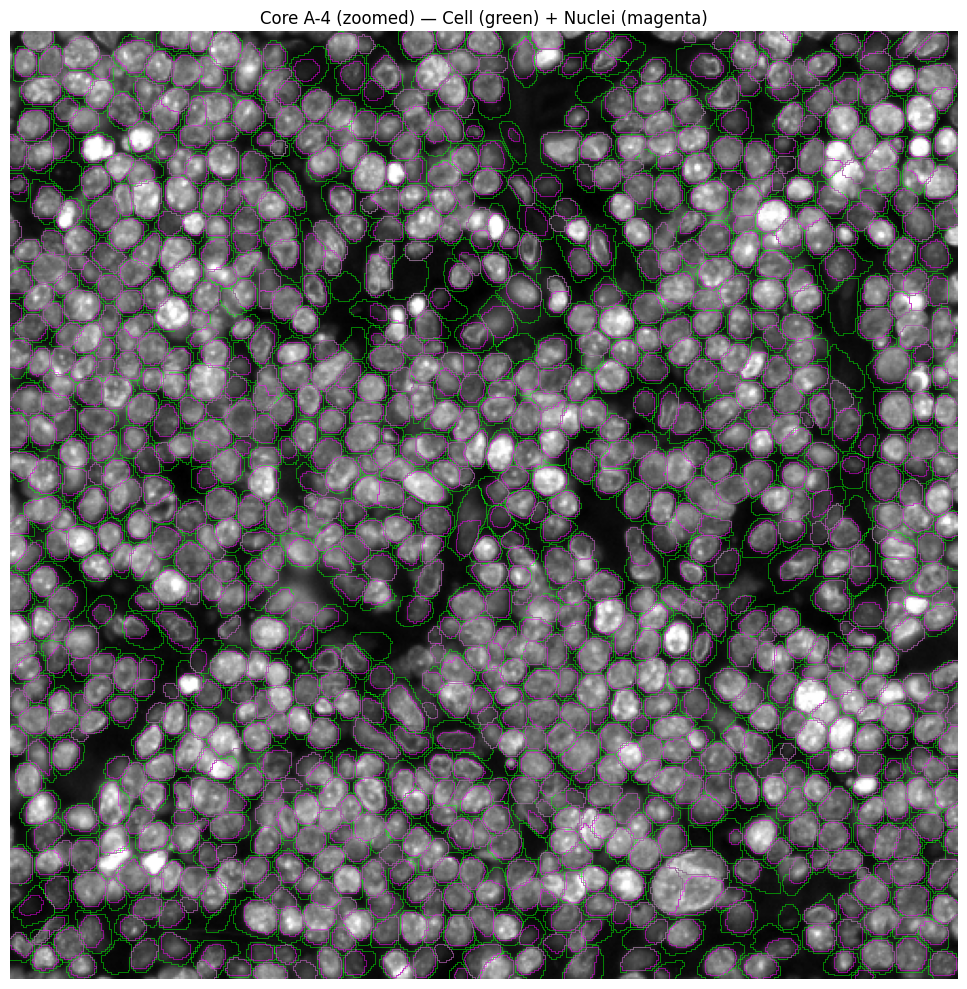

Cells in view: 1050, Nuclei in view: 1027


In [15]:
def get_points(coords):
    """Extract the first flat point list from possibly nested coordinate structures."""
    while coords and isinstance(coords[0], list) and isinstance(coords[0][0], list):
        coords = coords[0]
    return coords


fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(dapi_norm[y0:y1, x0:x1], cmap="gray", extent=[x0, x1, y1, y0])

# Overlay cell and nucleus boundaries for cells in this region
cell_patches = []
nuc_patches = []
for feat in cells["features"]:
    pts = get_points(feat["geometry"]["coordinates"][0])
    coords = np.array(pts)
    centroid = coords.mean(axis=0)
    if x0 <= centroid[0] <= x1 and y0 <= centroid[1] <= y1:
        cell_patches.append(Polygon(coords, closed=True))
        if "nucleusGeometry" in feat:
            nuc_pts = get_points(feat["nucleusGeometry"]["coordinates"][0])
            nuc_coords = np.array(nuc_pts)
            nuc_patches.append(Polygon(nuc_coords, closed=True))

ax.add_collection(
    PatchCollection(
        cell_patches, facecolor="none", edgecolor="lime", linewidth=0.5, alpha=0.7
    )
)
ax.add_collection(
    PatchCollection(
        nuc_patches, facecolor="none", edgecolor="magenta", linewidth=0.5, alpha=0.7
    )
)

ax.set_xlim(x0, x1)
ax.set_ylim(y1, y0)
ax.set_title(f"Core {core_name} (zoomed) — Cell (green) + Nuclei (magenta)")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Cells in view: {len(cell_patches)}, Nuclei in view: {len(nuc_patches)}")